# Book vs Phone Image Classification — R + EBImage + Keras
## Google Colab — Fixed v2

This notebook follows the supplied tutorial workflow:

**Read images → explore → resize → reshape → row-bind → one-hot encode → dense neural network → train → evaluate → predict.**

### Important
This version **does not use `rpy2`, `%%R`, or `install_keras()`**.

The previous error came from `install_keras(envname="/content/r-keras")`, which can fail in Colab because that API expects a managed environment name/path configuration that is not reliable in this setup.

Instead, this notebook:
1. installs R and EBImage,
2. installs TensorFlow/Keras into Colab's existing Python,
3. explicitly tells R/reticulate to use that Python,
4. runs the R implementation through `Rscript`.

### Dataset
Upload the ZIP containing:
- `p1.jpg`–`p6.jpg` = **Book**
- `c1.jpg`–`c6.jpg` = **Phone**

Training:
- Books: p1–p5
- Phones: c1–c5

Testing:
- p6 and c6

Model:
**256 ReLU → 128 ReLU → 2 Softmax**, RMSprop, categorical cross-entropy, 30 epochs.

In [1]:
# CELL 1 — Install R and system libraries
# Run this first.

!apt-get -qq update
!apt-get -qq install -y r-base r-base-dev \
    libcurl4-openssl-dev libssl-dev libxml2-dev \
    libfontconfig1-dev libfreetype6-dev \
    libpng-dev libjpeg-dev libtiff-dev \
    libfftw3-dev libmagick++-dev \
    libharfbuzz-dev libfribidi-dev

print("✓ R and system libraries installed.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Selecting previously unselected package fonts-droid-fallback.
(Reading database ... 118337 files and directories currently installed.)
Preparing to unpack .../00-fonts-droid-fallback_1%3a6.0.1r16-1.1build1_all.deb ...
Unpacking fonts-droid-fallback (1:6.0.1r16-1.1build1) ...
Selecting previously unselected package imagemagick-6-common.
Preparing to unpack .../01-imagemagick-6-common_8%3a6.9.11.60+dfsg-1.3ubuntu0.22.04.5_all.deb ...
Unpacking imagemagick-6-common (8:6.9.11.60+dfsg-1.3ubuntu0.22.04.5) ...
Selecting previously unselected package libmagickcore-6-headers.
Preparing to unpack .../02-libmagickcore-6-headers_8%3a6.9.11.60+dfsg-1.3ubuntu0.22.04.5_all.deb ...
Unpacking libmagickcore-6-headers (8:6.9.11.60+dfsg-1.3ubuntu0.22.04.5) ...
Selecting previousl

In [2]:
# CELL 2 — Upload the image ZIP
from google.colab import files
import os

uploaded = files.upload()

zip_files = [name for name in uploaded if name.lower().endswith(".zip")]
if not zip_files:
    raise FileNotFoundError("Please upload the ZIP containing the Book/Phone images.")

zip_name = zip_files[0]
zip_path = os.path.join("/content", zip_name)

print("✓ Uploaded:", zip_name)
print("Size:", os.path.getsize(zip_path), "bytes")

Saving book_phone_dataset.zip to book_phone_dataset.zip
✓ Uploaded: book_phone_dataset.zip
Size: 333281 bytes


In [3]:
# CELL 3 — Extract and locate the 12 required images
import os, zipfile, shutil

extract_dir = "/content/book_phone_raw"
dataset_dir = "/content/book_phone_dataset"

for d in [extract_dir, dataset_dir]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

expected = (
    [f"p{i}.jpg" for i in range(1,7)] +
    [f"c{i}.jpg" for i in range(1,7)]
)

# Search recursively so the ZIP may contain an extra top-level folder.
found = {}
for root, dirs, files_in_dir in os.walk(extract_dir):
    for f in files_in_dir:
        if f.lower() in [x.lower() for x in expected]:
            found[f.lower()] = os.path.join(root, f)

missing = [f for f in expected if f.lower() not in found]
if missing:
    raise FileNotFoundError(
        "Missing required images: " + ", ".join(missing) +
        "\nThe ZIP must contain p1.jpg-p6.jpg and c1.jpg-c6.jpg."
    )

# Copy into one flat directory with exact names.
for f in expected:
    shutil.copy2(found[f.lower()], os.path.join(dataset_dir, f))

print("✓ All 12 images found:")
for f in expected:
    print("  ✓", f)

print("\nDataset directory:", dataset_dir)

✓ All 12 images found:
  ✓ p1.jpg
  ✓ p2.jpg
  ✓ p3.jpg
  ✓ p4.jpg
  ✓ p5.jpg
  ✓ p6.jpg
  ✓ c1.jpg
  ✓ c2.jpg
  ✓ c3.jpg
  ✓ c4.jpg
  ✓ c5.jpg
  ✓ c6.jpg

Dataset directory: /content/book_phone_dataset


In [4]:
# CELL 4 — Install required R packages
# This can take a few minutes, especially EBImage.

import subprocess, textwrap

r_install = r'''
options(repos = c(CRAN = "https://cloud.r-project.org"))

if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager", quiet = TRUE)
}

if (!requireNamespace("EBImage", quietly = TRUE)) {
  BiocManager::install("EBImage", ask = FALSE, update = FALSE, quiet = TRUE)
}

if (!requireNamespace("reticulate", quietly = TRUE)) {
  install.packages("reticulate", quiet = TRUE)
}

if (!requireNamespace("keras3", quietly = TRUE)) {
  install.packages("keras3", quiet = TRUE)
}

cat("✓ R packages ready: EBImage, reticulate, keras3\n")
'''

open("/content/install_r_packages.R", "w").write(r_install)

result = subprocess.run(
    ["Rscript", "/content/install_r_packages.R"],
    text=True,
    capture_output=True
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("R package installation failed.")

print("✓ CELL 4 completed.")

✓ R packages ready: EBImage, reticulate, keras3

✓ CELL 4 completed.


In [5]:
# CELL 5 — FIXED TensorFlow/Keras setup
# IMPORTANT: This replaces the failing install_keras(envname="/content/r-keras") cell.
#
# We install TensorFlow + Keras into Colab's EXISTING Python environment and then
# explicitly point R/reticulate to that same Python executable.

import sys, subprocess, os

python_exe = sys.executable
print("Colab Python:", python_exe)
print("Python version:", sys.version)

# Upgrade pip first.
subprocess.run(
    [python_exe, "-m", "pip", "install", "-q", "--upgrade", "pip"],
    check=True
)

# Install TensorFlow and Keras into the same Python used by this Colab runtime.
subprocess.run(
    [python_exe, "-m", "pip", "install", "-q", "tensorflow", "keras"],
    check=True
)

# Verify imports from Python.
verify = subprocess.run(
    [
        python_exe, "-c",
        "import tensorflow as tf, keras; "
        "print('TensorFlow:', tf.__version__); "
        "print('Keras:', keras.__version__)"
    ],
    text=True,
    capture_output=True
)

print(verify.stdout)
if verify.returncode != 0:
    print(verify.stderr)
    raise RuntimeError("TensorFlow/Keras Python installation failed.")

# Save the exact Python executable for the R script.
with open("/content/colab_python_path.txt", "w") as f:
    f.write(python_exe)

# Verify that R can see the same Python and TensorFlow.
r_verify = r'''
library(reticulate)

python_path <- readLines("/content/colab_python_path.txt", n = 1)
use_python(python_path, required = TRUE)

cat("R/reticulate Python:", py_config()$python, "\n")

tf <- import("tensorflow")
keras <- import("keras")

cat("TensorFlow visible to R:", tf$`__version__`, "\n")
cat("Keras visible to R:", keras$`__version__`, "\n")
cat("✓ R can access TensorFlow/Keras.\n")
'''

open("/content/verify_r_tensorflow.R", "w").write(r_verify)

r_result = subprocess.run(
    ["Rscript", "/content/verify_r_tensorflow.R"],
    text=True,
    capture_output=True
)

print(r_result.stdout)
if r_result.returncode != 0:
    print("R verification error:")
    print(r_result.stderr)
    raise RuntimeError(
        "R cannot access TensorFlow/Keras. "
        "Restart the Colab runtime once and run all cells again."
    )

print("✓ CELL 5 completed successfully.")

Colab Python: /usr/bin/python3
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.20.0
Keras: 3.13.2

R/reticulate Python: /usr/bin/python3 
TensorFlow visible to R: 2.20.0 
Keras visible to R: 3.13.2 
✓ R can access TensorFlow/Keras.

✓ CELL 5 completed successfully.


## R implementation

The next cell writes the complete R program and executes it with `Rscript`.

No `%%R` magic is required.

In [6]:
# CELL 6 — Complete R implementation
import subprocess, os

r_code = r'''
# ============================================================
# BOOK VS PHONE IMAGE CLASSIFICATION
# R + EBImage + keras3 + TensorFlow
# ============================================================

options(repos = c(CRAN = "https://cloud.r-project.org"))

# Use the exact Python executable from the Colab runtime.
python_path <- readLines("/content/colab_python_path.txt", n = 1)
Sys.setenv(RETICULATE_PYTHON = python_path)

library(EBImage)
library(keras3)
library(reticulate)

use_python(python_path, required = TRUE)

cat("\n===== PYTHON CONFIGURATION =====\n")
print(py_config())

# Select TensorFlow backend.
use_backend("tensorflow")

set.seed(123)

# ------------------------------------------------------------
# 1. Read images
# ------------------------------------------------------------
setwd("/content/book_phone_dataset")

pics <- c(
  "p1.jpg","p2.jpg","p3.jpg","p4.jpg","p5.jpg","p6.jpg",
  "c1.jpg","c2.jpg","c3.jpg","c4.jpg","c5.jpg","c6.jpg"
)

mypic <- vector("list", length(pics))

for (i in seq_along(pics)) {
  mypic[[i]] <- readImage(pics[i])
}

cat("\n===== IMAGE INFORMATION =====\n")
cat("Number of images:", length(mypic), "\n")
cat("First image dimensions:", paste(dim(mypic[[1]]), collapse = " x "), "\n")
print(summary(mypic[[1]]))
str(mypic, max.level = 1)

# ------------------------------------------------------------
# 2. Explore images
# ------------------------------------------------------------
png("/content/book_example.png", width = 700, height = 500)
display(mypic[[1]], method = "raster")
dev.off()

png("/content/phone_example.png", width = 700, height = 500)
display(mypic[[7]], method = "raster")
dev.off()

png("/content/image_histogram.png", width = 700, height = 500)
hist(mypic[[2]], main = "Pixel Histogram: Book Image p2")
dev.off()

# ------------------------------------------------------------
# 3. Resize to 28 x 28 x 3
# 28 * 28 * 3 = 2352 input values
# ------------------------------------------------------------
for (i in seq_along(mypic)) {
  mypic[[i]] <- channel(mypic[[i]], "rgb")
  mypic[[i]] <- resize(mypic[[i]], w = 28, h = 28)
}

cat("\n===== AFTER RESIZE =====\n")
print(dim(mypic[[1]]))

# ------------------------------------------------------------
# 4. Flatten / reshape
# ------------------------------------------------------------
for (i in seq_along(mypic)) {
  arr <- as.array(mypic[[i]])
  mypic[[i]] <- array_reshape(arr, c(2352))
}

cat("\n===== AFTER RESHAPE =====\n")
print(dim(mypic[[1]]))

# ------------------------------------------------------------
# 5. Training and testing data
# ------------------------------------------------------------
# Book = 0
# Phone = 1

trainx <- NULL

for (i in 1:5) {
  trainx <- rbind(trainx, mypic[[i]])
}

for (i in 7:11) {
  trainx <- rbind(trainx, mypic[[i]])
}

testx <- rbind(mypic[[6]], mypic[[12]])

trainx <- pmin(pmax(trainx, 0), 1)
testx  <- pmin(pmax(testx, 0), 1)

trainy <- c(0,0,0,0,0,1,1,1,1,1)
testy  <- c(0,1)

cat("\n===== DATA SHAPES =====\n")
cat("trainx:", paste(dim(trainx), collapse = " x "), "\n")
cat("testx :", paste(dim(testx), collapse = " x "), "\n")
cat("trainy:", paste(trainy, collapse = ", "), "\n")
cat("testy :", paste(testy, collapse = ", "), "\n")

# ------------------------------------------------------------
# 6. One-hot encoding
# ------------------------------------------------------------
trainLabels <- to_categorical(trainy, num_classes = 2)
testLabels  <- to_categorical(testy, num_classes = 2)

cat("\n===== ONE-HOT TRAIN LABELS =====\n")
print(trainLabels)

# ------------------------------------------------------------
# 7. Model
# ------------------------------------------------------------
model <- keras_model_sequential(input_shape = c(2352)) |>
  layer_dense(units = 256, activation = "relu") |>
  layer_dense(units = 128, activation = "relu") |>
  layer_dense(units = 2, activation = "softmax")

cat("\n===== MODEL =====\n")
print(model)

# ------------------------------------------------------------
# 8. Compile
# ------------------------------------------------------------
model |> compile(
  loss = "categorical_crossentropy",
  optimizer = optimizer_rmsprop(),
  metrics = c("accuracy")
)

# ------------------------------------------------------------
# 9. Train
# ------------------------------------------------------------
cat("\n===== TRAINING =====\n")

history <- model |> fit(
  x = trainx,
  y = trainLabels,
  epochs = 30,
  batch_size = 2,
  validation_split = 0.2,
  verbose = 1
)

# ------------------------------------------------------------
# 10. Training history
# ------------------------------------------------------------
png("/content/training_history.png", width = 900, height = 600)
plot(history, main = "Book vs Phone Training History")
dev.off()

# ------------------------------------------------------------
# 11. Evaluate
# ------------------------------------------------------------
cat("\n===== TRAINING EVALUATION =====\n")
train_eval <- evaluate(model, trainx, trainLabels, verbose = 0)
print(train_eval)

cat("\n===== TEST EVALUATION =====\n")
test_eval <- evaluate(model, testx, testLabels, verbose = 0)
print(test_eval)

# ------------------------------------------------------------
# 12. Predictions on training data
# ------------------------------------------------------------
train_prob <- predict(model, trainx, verbose = 0)
train_pred <- max.col(train_prob) - 1L

cat("\n===== TRAINING CONFUSION TABLE =====\n")
print(table(Predicted = train_pred, Actual = trainy))

# ------------------------------------------------------------
# 13. Predictions on test data
# ------------------------------------------------------------
test_prob <- predict(model, testx, verbose = 0)
test_pred <- max.col(test_prob) - 1L

class_names <- c("Book", "Phone")

test_results <- data.frame(
  Image = c("p6.jpg", "c6.jpg"),
  Actual_Class = class_names[testy + 1],
  Predicted_Class = class_names[test_pred + 1],
  Book_Probability = round(test_prob[,1], 6),
  Phone_Probability = round(test_prob[,2], 6),
  Correct = test_pred == testy
)

cat("\n===== TEST PREDICTIONS =====\n")
print(test_results)

cat("\n===== TEST CONFUSION MATRIX =====\n")
print(
  table(
    Predicted = factor(test_pred, levels = 0:1, labels = class_names),
    Actual = factor(testy, levels = 0:1, labels = class_names)
  )
)

# ------------------------------------------------------------
# 14. Save deliverables
# ------------------------------------------------------------
write.csv(
  test_results,
  "/content/book_phone_test_predictions.csv",
  row.names = FALSE
)

write.csv(
  data.frame(
    Method = c("Training", "Test"),
    Accuracy = c(
      mean(train_pred == trainy),
      mean(test_pred == testy)
    )
  ),
  "/content/book_phone_accuracy.csv",
  row.names = FALSE
)

# Save model.
save_model(
  model,
  "/content/book_phone_model.keras",
  overwrite = TRUE
)

cat("\n===== COMPLETE =====\n")
cat("Generated:\n")
cat("✓ book_phone_image_classification.R\n")
cat("✓ book_phone_test_predictions.csv\n")
cat("✓ book_phone_accuracy.csv\n")
cat("✓ book_phone_model.keras\n")
cat("✓ training_history.png\n")
cat("✓ book_example.png\n")
cat("✓ phone_example.png\n")
cat("✓ image_histogram.png\n")
'''

r_path = "/content/book_phone_image_classification.R"
open(r_path, "w").write(r_code)

result = subprocess.run(
    ["Rscript", r_path],
    text=True,
    capture_output=True
)

print(result.stdout)

if result.returncode != 0:
    print("\n===== R ERROR =====")
    print(result.stderr)
    raise RuntimeError("The R classification script failed. Read the R error above.")

print("\n✓ CELL 6 completed successfully.")


===== PYTHON CONFIGURATION =====
python:         /usr/bin/python3
libpython:      /usr/lib/python3.12/config-3.12-x86_64-linux-gnu/libpython3.12.so
pythonhome:     //usr://usr
version:        3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
numpy:          /usr/local/lib/python3.12/dist-packages/numpy
numpy_version:  2.0.2
keras:          /usr/local/lib/python3.12/dist-packages/keras

NOTE: Python version was forced by RETICULATE_PYTHON

===== IMAGE INFORMATION =====
Number of images: 12 
First image dimensions: 323 x 329 x 3 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.05882 0.23529 0.34781 0.63137 1.00000 
List of 12
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
 $ :For


book_example.png


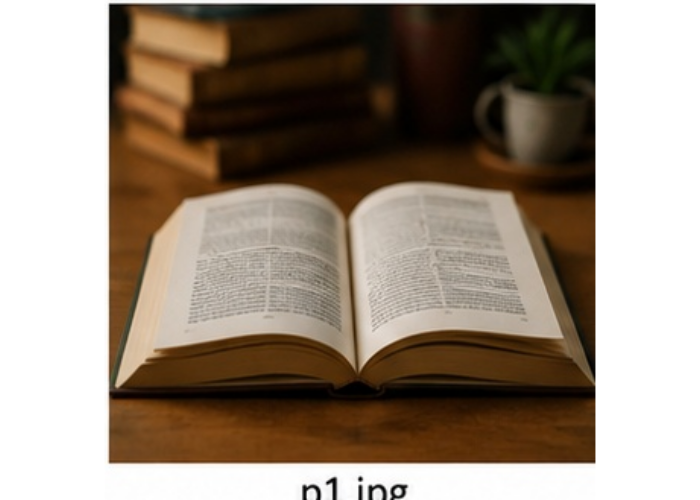


phone_example.png


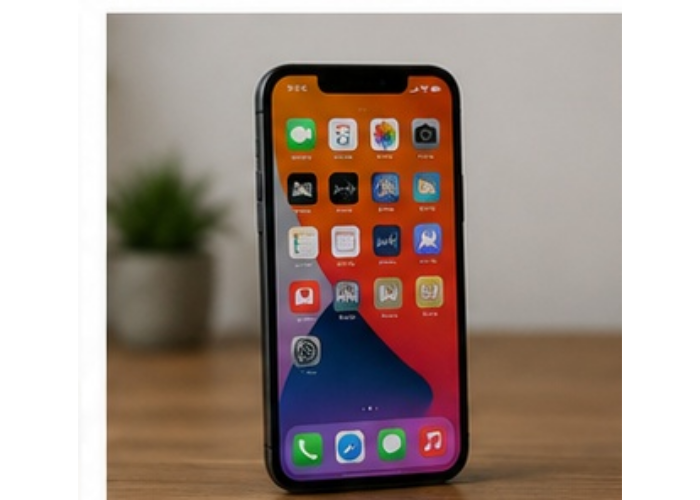


image_histogram.png


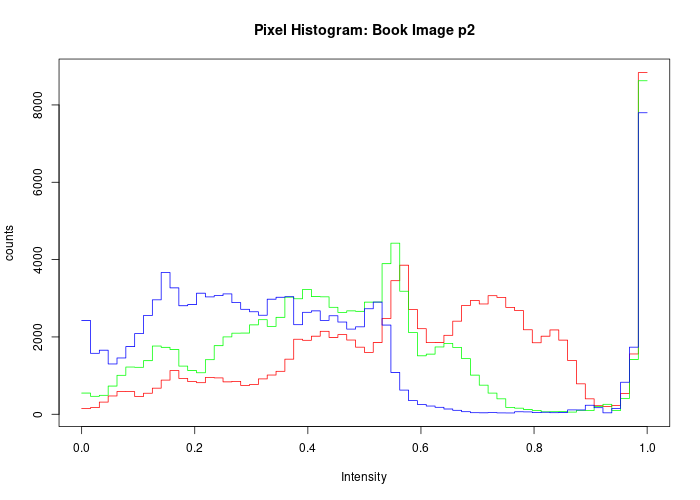


training_history.png


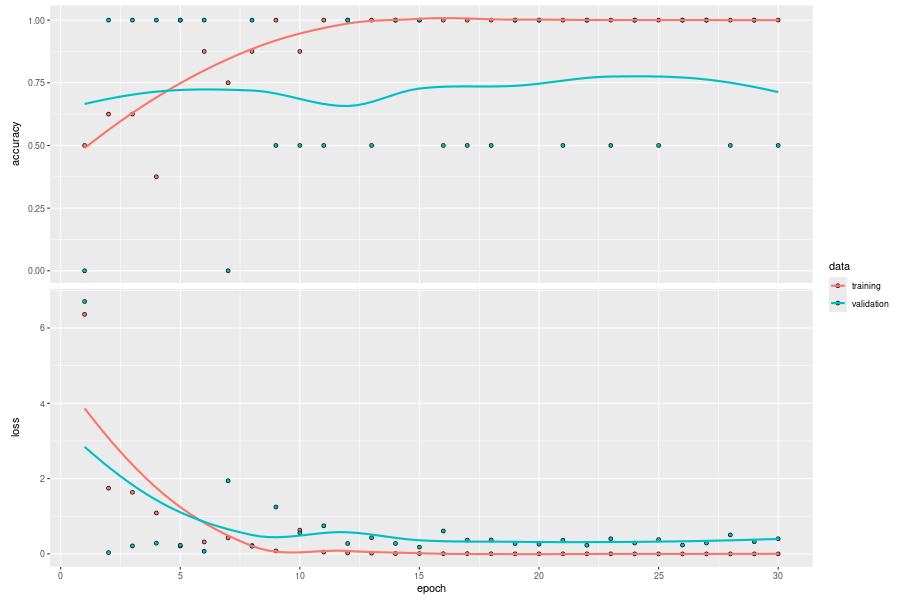


===== TEST PREDICTIONS =====


,Image,Actual_Class,Predicted_Class,Book_Probability,Phone_Probability,Correct
0,p6.jpg,Book,Phone,0.021114,0.978886,False
1,c6.jpg,Phone,Phone,0.036608,0.963392,True



===== ACCURACY =====


,Method,Accuracy
0,Training,0.9
1,Test,0.5


In [7]:
# CELL 7 — Display generated plots and results
from IPython.display import display, Image
import pandas as pd
import os

for path in [
    "/content/book_example.png",
    "/content/phone_example.png",
    "/content/image_histogram.png",
    "/content/training_history.png"
]:
    if os.path.exists(path):
        print("\n" + os.path.basename(path))
        display(Image(filename=path))

print("\n===== TEST PREDICTIONS =====")
display(pd.read_csv("/content/book_phone_test_predictions.csv"))

print("\n===== ACCURACY =====")
display(pd.read_csv("/content/book_phone_accuracy.csv"))

In [8]:
# CELL 8 — Create ONE final ZIP containing the submission deliverables

import zipfile, os

output_files = [
    "/content/book_phone_image_classification.R",
    "/content/book_phone_test_predictions.csv",
    "/content/book_phone_accuracy.csv",
    "/content/book_phone_model.keras",
    "/content/training_history.png",
    "/content/book_example.png",
    "/content/phone_example.png",
    "/content/image_histogram.png",
]

zip_out = "/content/Book_vs_Phone_R_Keras_FINAL.zip"

with zipfile.ZipFile(zip_out, "w", zipfile.ZIP_DEFLATED) as z:
    for path in output_files:
        if os.path.exists(path):
            z.write(path, arcname=os.path.basename(path))

print("✓ FINAL ZIP CREATED")
print(zip_out)

with zipfile.ZipFile(zip_out, "r") as z:
    print("\nZIP CONTENTS:")
    for name in z.namelist():
        print("  ✓", name)

print("\nYou can download the ZIP from the Colab file browser.")

✓ FINAL ZIP CREATED
/content/Book_vs_Phone_R_Keras_FINAL.zip

ZIP CONTENTS:
  ✓ book_phone_image_classification.R
  ✓ book_phone_test_predictions.csv
  ✓ book_phone_accuracy.csv
  ✓ book_phone_model.keras
  ✓ training_history.png
  ✓ book_example.png
  ✓ phone_example.png
  ✓ image_histogram.png

You can download the ZIP from the Colab file browser.
